# Temporal Analysis

In order to perform time based analytics and visualisations linked to a listing, which is essential to understand location market dynamics, the dataset `reviews_milan` is merged with `listings_milan_clean` to create a comprehensive view of how reviews (as a proxy for demand) evolve over time in relation to listing attributes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Load datasets
reviews_path = 'Data/reviews_milan.csv'
listings_path = 'Data/listings_milan_clean.csv'

reviews = pd.read_csv(reviews_path, parse_dates=['date'])
listings = pd.read_csv(listings_path)

print('reviews shape:', reviews.shape)
print('listings shape:', listings.shape)
display(reviews.head())
display(listings.head(3))

reviews shape: (981739, 2)
listings shape: (20357, 25)


,listing_id,date
0,23986,2012-04-24
1,23986,2015-09-21
2,23986,2016-04-16
3,23986,2016-07-30
4,23986,2016-08-22


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,is_entire_home,is_professional_host,is_long_term,is_active,has_license,host_tier,nights_tier,lic_category
0,23986,""" Characteristic Milanese flat""",95941,Jeremy,Navigli,45.448060,9.173730,Entire home/apt,180.0,31,26,2024-04-20,0.16,1,362,0,NaN,True,False,True,False,False,1 (privato),≥30 notti,Mancante
1,46536,Nico & Cinzia's Pink Suite!,138683,Nico&Cinzia,Viale Monza,45.522760,9.224780,Entire home/apt,86.0,3,39,2025-04-20,0.23,1,111,2,IT015209C2BBKGCMT7,True,False,False,True,True,1 (privato),1–6 notti,Altro/Non valido
2,84741,Nice room with private bathroom,443989,Francesca,Parco Forlanini - Ortica,45.469994,9.244106,Private room,36.0,31,690,2025-08-23,3.94,3,165,63,"I applied for a CIN, but haven’t received it yet",False,False,True,True,True,2–5,≥30 notti,In attesa


In [3]:
# Basic quality checks
print('Nulls in reviews:')
display(reviews.isna().sum())

print('Duplicate review rows:', reviews.duplicated().sum())
print('Unique listing_id in reviews:', reviews['listing_id'].nunique())
print('Date range:', reviews['date'].min(), 'to', reviews['date'].max())

Nulls in reviews:


listing_id    0
date          0
dtype: int64

Duplicate review rows: 908
Unique listing_id in reviews: 19522
Date range: 2010-12-20 00:00:00 to 2025-09-24 00:00:00


In [4]:
# Prepare join keys and merge
listings = listings.rename(columns={'id': 'listing_id'})

merged = reviews.merge(listings, on='listing_id', how='left', validate='many_to_one')

match_rate = merged['name'].notna().mean()
print(f'Merge match rate on listing_id: {match_rate:.2%}')
print('Rows after merge:', merged.shape[0])
display(merged.head())

Merge match rate on listing_id: 93.61%
Rows after merge: 981739


,listing_id,date,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,is_entire_home,is_professional_host,is_long_term,is_active,has_license,host_tier,nights_tier,lic_category
0,23986,2012-04-24,""" Characteristic Milanese flat""",95941.0,Jeremy,Navigli,45.44806,9.17373,Entire home/apt,180.0,31.0,26.0,2024-04-20,0.16,1.0,362.0,0.0,NaN,True,False,True,False,False,1 (privato),≥30 notti,Mancante
1,23986,2015-09-21,""" Characteristic Milanese flat""",95941.0,Jeremy,Navigli,45.44806,9.17373,Entire home/apt,180.0,31.0,26.0,2024-04-20,0.16,1.0,362.0,0.0,NaN,True,False,True,False,False,1 (privato),≥30 notti,Mancante
2,23986,2016-04-16,""" Characteristic Milanese flat""",95941.0,Jeremy,Navigli,45.44806,9.17373,Entire home/apt,180.0,31.0,26.0,2024-04-20,0.16,1.0,362.0,0.0,NaN,True,False,True,False,False,1 (privato),≥30 notti,Mancante
3,23986,2016-07-30,""" Characteristic Milanese flat""",95941.0,Jeremy,Navigli,45.44806,9.17373,Entire home/apt,180.0,31.0,26.0,2024-04-20,0.16,1.0,362.0,0.0,NaN,True,False,True,False,False,1 (privato),≥30 notti,Mancante
4,23986,2016-08-22,""" Characteristic Milanese flat""",95941.0,Jeremy,Navigli,45.44806,9.17373,Entire home/apt,180.0,31.0,26.0,2024-04-20,0.16,1.0,362.0,0.0,NaN,True,False,True,False,False,1 (privato),≥30 notti,Mancante


In [5]:
# Temporal feature engineering
merged['year'] = merged['date'].dt.year
merged['month'] = merged['date'].dt.month
merged['year_month'] = merged['date'].dt.to_period('M').dt.to_timestamp()
merged['quarter'] = merged['date'].dt.to_period('Q').astype(str)
merged['week_start'] = merged['date'] - pd.to_timedelta(merged['date'].dt.weekday, unit='D')

display(merged[['listing_id', 'date', 'year_month', 'room_type', 'neighbourhood']].head())

,listing_id,date,year_month,room_type,neighbourhood
0,23986,2012-04-24,2012-04-01,Entire home/apt,Navigli
1,23986,2015-09-21,2015-09-01,Entire home/apt,Navigli
2,23986,2016-04-16,2016-04-01,Entire home/apt,Navigli
3,23986,2016-07-30,2016-07-01,Entire home/apt,Navigli
4,23986,2016-08-22,2016-08-01,Entire home/apt,Navigli


## 1. Global Temporal Dynamics
We first examine overall review volume over time as a proxy for demand/activity.

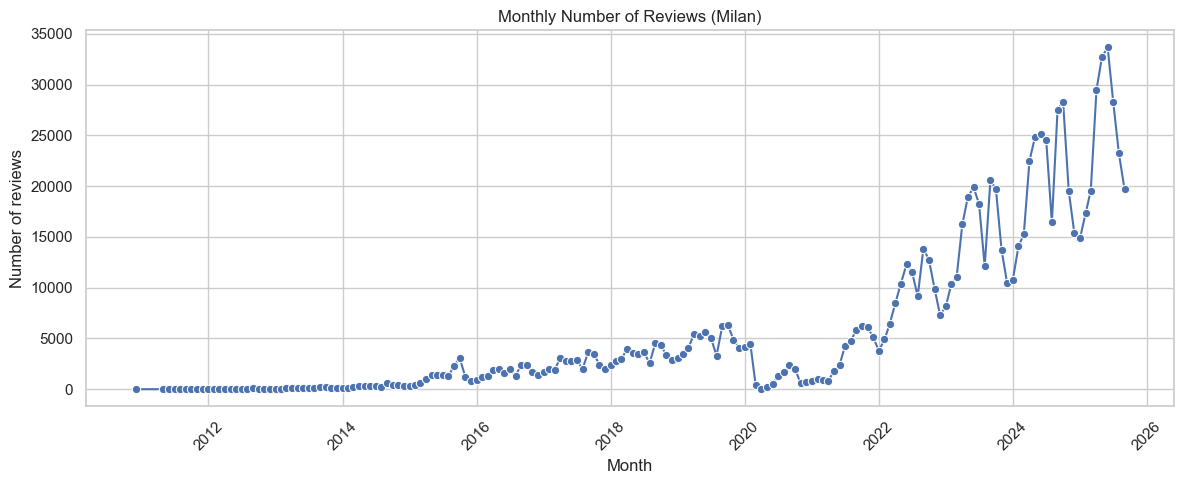

,year_month,n_reviews
169,2025-05-01,32747
170,2025-06-01,33667
171,2025-07-01,28343
172,2025-08-01,23249
173,2025-09-01,19689


In [6]:
monthly_reviews = (
    merged.groupby('year_month', as_index=False)
    .size()
    .rename(columns={'size': 'n_reviews'})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=monthly_reviews, x='year_month', y='n_reviews', marker='o', ax=ax)
ax.set_title('Monthly Number of Reviews (Milan)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly_reviews.tail())

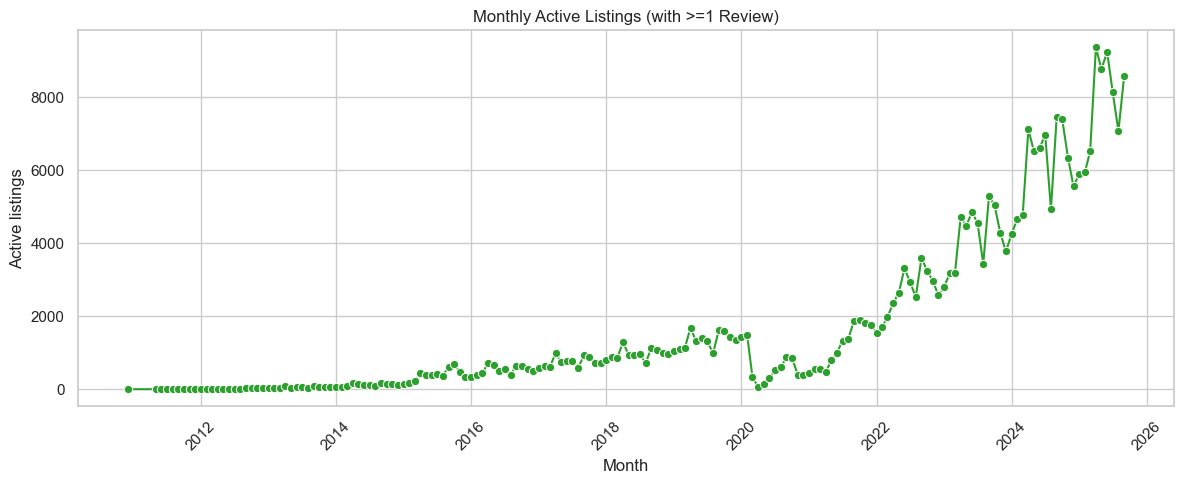

In [7]:
# Active listings per month: distinct listings receiving at least one review
active_listings_monthly = (
    merged.groupby('year_month', as_index=False)['listing_id']
    .nunique()
    .rename(columns={'listing_id': 'active_listings'})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=active_listings_monthly, x='year_month', y='active_listings', marker='o', color='tab:green', ax=ax)
ax.set_title('Monthly Active Listings (with >=1 Review)')
ax.set_xlabel('Month')
ax.set_ylabel('Active listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Composition Over Time
How does review activity evolve across listing categories?

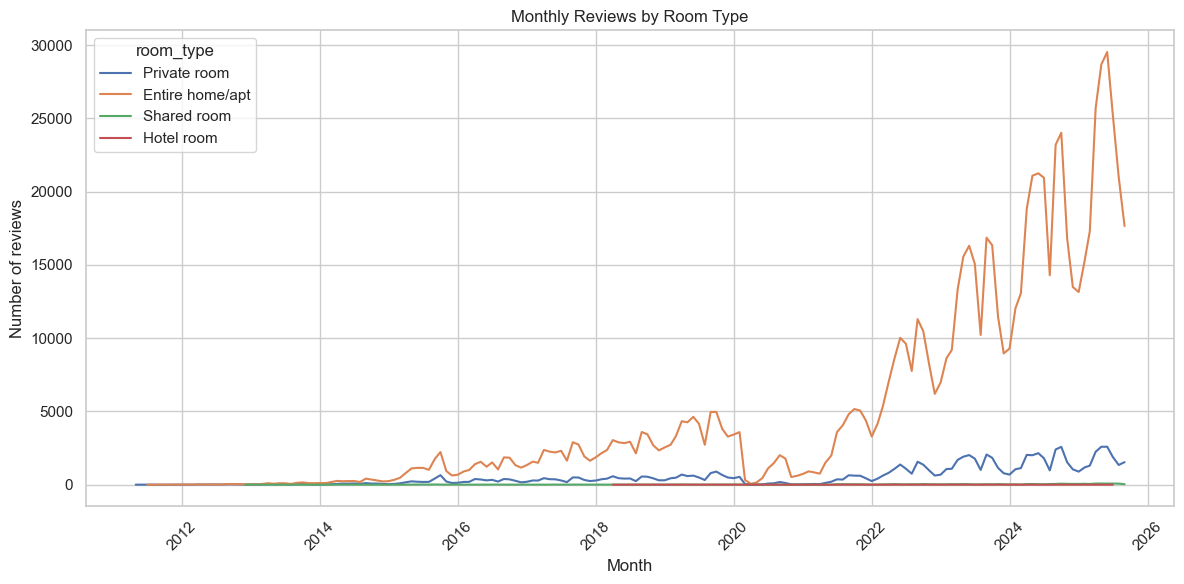

In [8]:
monthly_room_type = (
    merged.dropna(subset=['room_type'])
    .groupby(['year_month', 'room_type'], as_index=False)
    .size()
    .rename(columns={'size': 'n_reviews'})
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=monthly_room_type, x='year_month', y='n_reviews', hue='room_type', ax=ax)
ax.set_title('Monthly Reviews by Room Type')
ax.set_xlabel('Month')
ax.set_ylabel('Number of reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

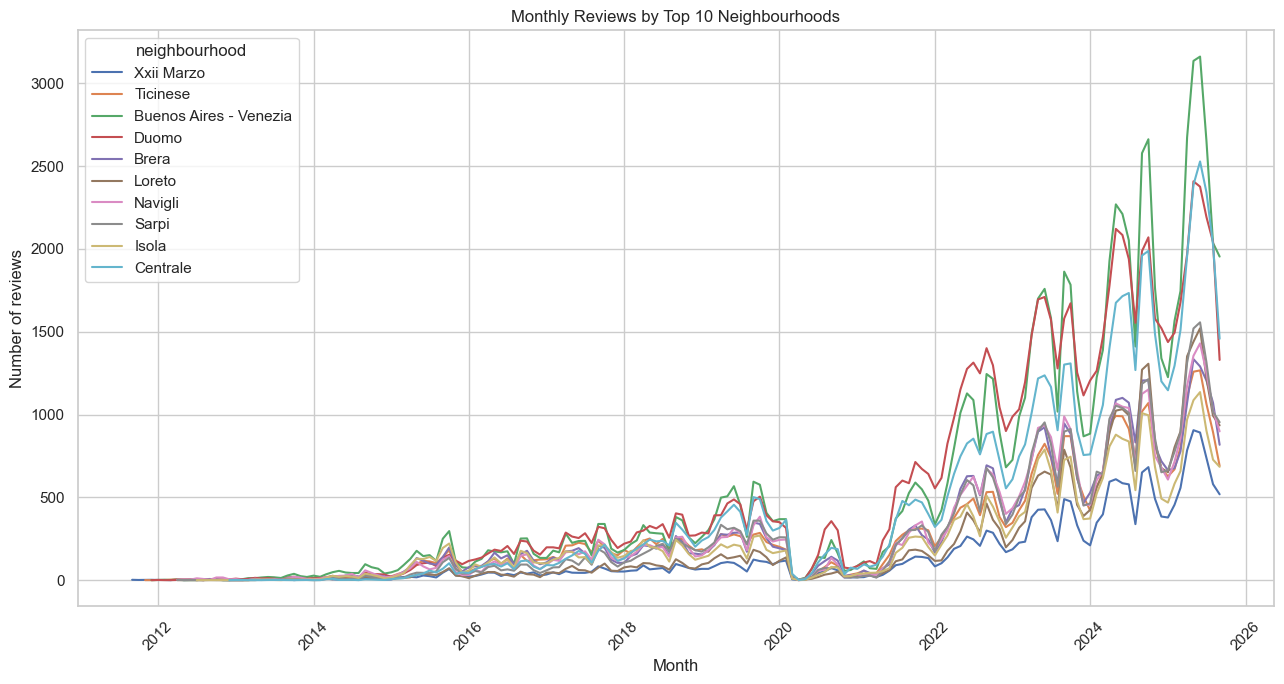

In [9]:
# Top neighbourhoods by total review volume for cleaner plotting
top_n = 10
top_neighbourhoods = (
    merged['neighbourhood']
    .value_counts(dropna=True)
    .head(top_n)
    .index
)

monthly_neigh = (
    merged[merged['neighbourhood'].isin(top_neighbourhoods)]
    .groupby(['year_month', 'neighbourhood'], as_index=False)
    .size()
    .rename(columns={'size': 'n_reviews'})
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.lineplot(data=monthly_neigh, x='year_month', y='n_reviews', hue='neighbourhood', ax=ax)
ax.set_title('Monthly Reviews by Top 10 Neighbourhoods')
ax.set_xlabel('Month')
ax.set_ylabel('Number of reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Review Intensity Metrics
Two simple indicators:
- Reviews per active listing each month
- Year-over-year monthly comparison

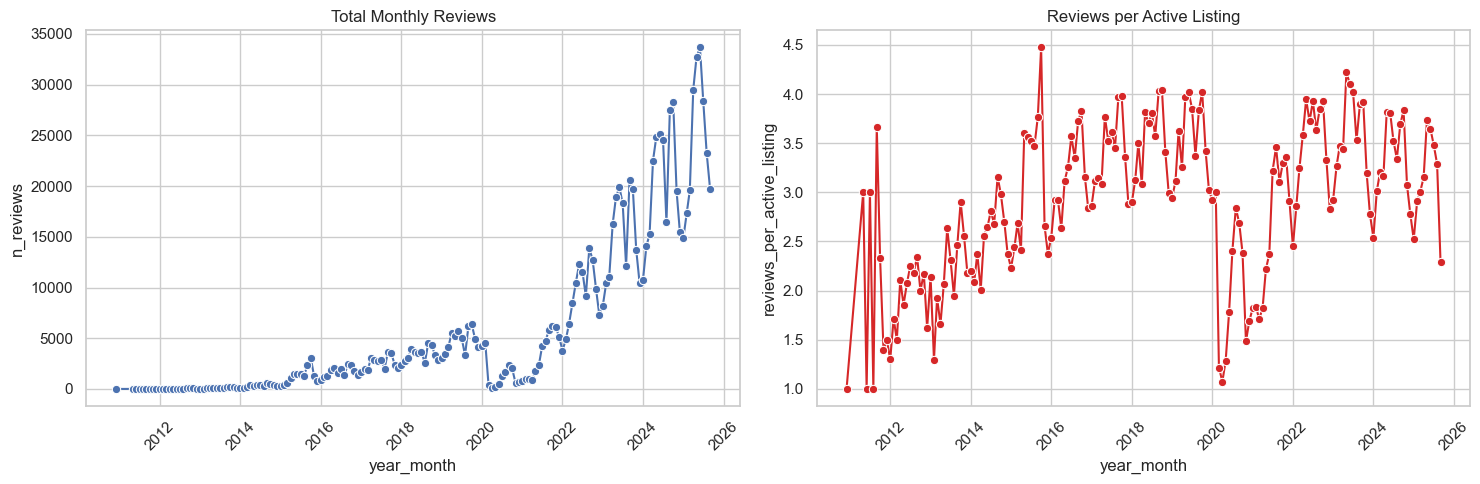

,year_month,n_reviews,active_listings,reviews_per_active_listing
169,2025-05-01,32747,8768,3.734831
170,2025-06-01,33667,9233,3.646377
171,2025-07-01,28343,8132,3.485366
172,2025-08-01,23249,7069,3.288867
173,2025-09-01,19689,8579,2.295023


In [10]:
monthly_kpis = monthly_reviews.merge(active_listings_monthly, on='year_month', how='left')
monthly_kpis['reviews_per_active_listing'] = monthly_kpis['n_reviews'] / monthly_kpis['active_listings']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=monthly_kpis, x='year_month', y='n_reviews', marker='o', ax=axes[0])
axes[0].set_title('Total Monthly Reviews')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly_kpis, x='year_month', y='reviews_per_active_listing', marker='o', color='tab:red', ax=axes[1])
axes[1].set_title('Reviews per Active Listing')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(monthly_kpis.tail())

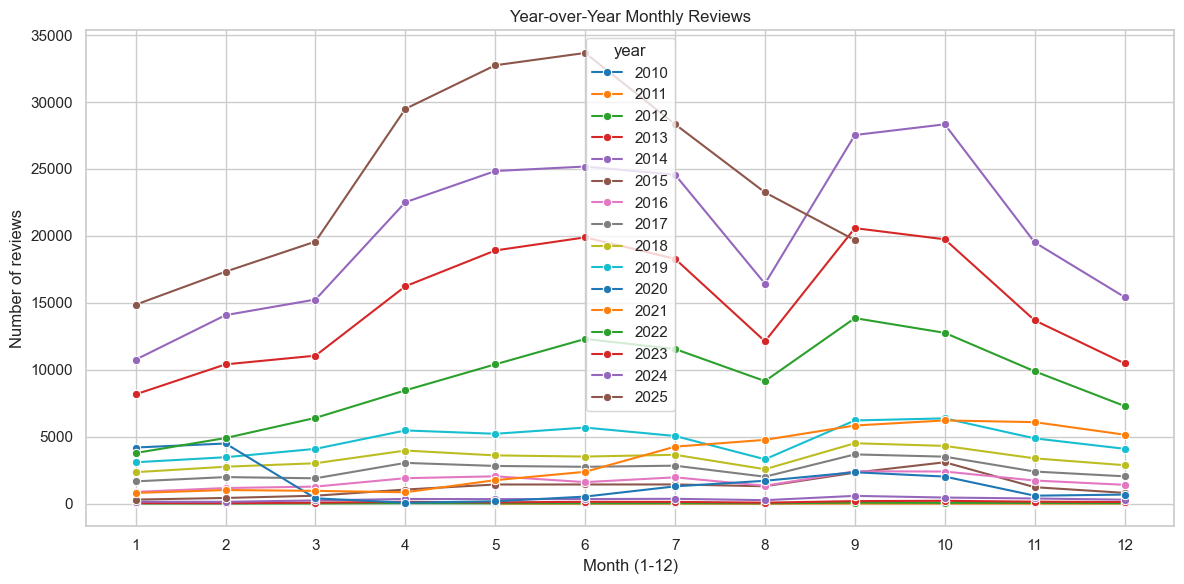

In [11]:
# Year-over-year seasonality view
yoy = monthly_kpis.copy()
yoy['year'] = yoy['year_month'].dt.year
yoy['month'] = yoy['year_month'].dt.month

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=yoy, x='month', y='n_reviews', hue='year', marker='o', palette='tab10', ax=ax)
ax.set_title('Year-over-Year Monthly Reviews')
ax.set_xlabel('Month (1-12)')
ax.set_ylabel('Number of reviews')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 4. Optional: Link to Listing-Level Attributes
You can now test temporal hypotheses, for example:
- Are professional hosts more stable over time?
- Do entire-home listings react differently across seasons?
- Are trends concentrated in specific neighbourhoods?

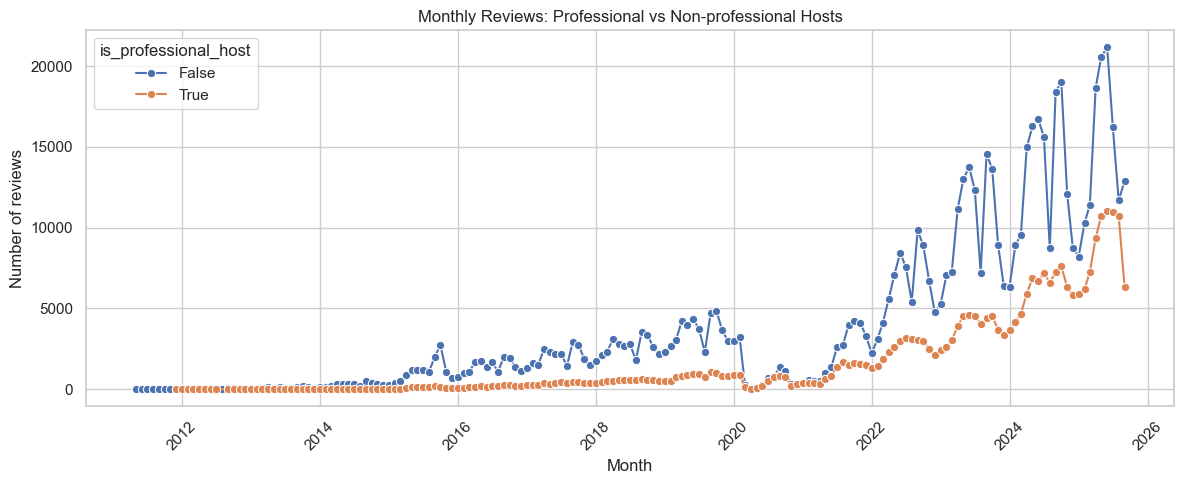

In [12]:
# Example: professional vs non-professional host dynamics
if 'is_professional_host' in merged.columns:
    prof_ts = (
        merged.dropna(subset=['is_professional_host'])
        .groupby(['year_month', 'is_professional_host'], as_index=False)
        .size()
        .rename(columns={'size': 'n_reviews'})
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=prof_ts, x='year_month', y='n_reviews', hue='is_professional_host', marker='o', ax=ax)
    ax.set_title('Monthly Reviews: Professional vs Non-professional Hosts')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of reviews')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Column is_professional_host not found in listings data.')